# OpenCivitas FSC 2025 RSO — validazione dati

Notebook tecnico. Genera le figure per il README.

**Dataset**: `opencivitas_fsc_2025_rso` (OpenCivitas/Sogei) via GCS clean parquet.
**Copertura**: 6.573 comuni RSO, dati 2025.

Per la narrativa completa vedi il [README](../README.md).


In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import display

pd.options.display.float_format = '{:,.0f}'.format
plt.rcParams['figure.dpi'] = 150

con = duckdb.connect()
con.execute('INSTALL httpfs; LOAD httpfs;')

GCS = 'gs://dataciviclab-clean/opencivitas_fsc_2025_rso/*/opencivitas_fsc_2025_rso_*_clean.parquet'

cnt = con.execute(f"SELECT count(*) FROM read_parquet('{GCS}') WHERE regione != 'ITALIA'").fetchone()[0]
print(f"Comuni RSO: {cnt:,}")

Comuni RSO: 6,572


In [2]:
# 1. Correlazione capacita fiscale vs fondo perequativo
corr = con.execute(f"""
    SELECT
        ROUND(CORR(capacita_fiscale / NULLIF(popolazione, 0),
                   fondo_perequativo / NULLIF(popolazione, 0)), 3) AS corr_cf_fp,
        ROUND(CORR(capacita_fiscale / NULLIF(popolazione, 0),
                   dotazione_finale_fsc / NULLIF(popolazione, 0)), 3) AS corr_cf_df
    FROM read_parquet('{GCS}')
    WHERE regione != 'ITALIA' AND popolazione > 0
""").fetchdf()
display(corr)

print(f"Corr CF vs FP: {corr.iloc[0]['corr_cf_fp']} (negativa = il meccanismo funziona)")
print(f"Corr CF vs DF: {corr.iloc[0]['corr_cf_df']} (negativa = redistribuzione parziale)")

,corr_cf_fp,corr_cf_df
0,-1,-1


Corr CF vs FP: -0.784 (negativa = il meccanismo funziona)
Corr CF vs DF: -0.636 (negativa = redistribuzione parziale)


In [3]:
# 2. Per regione: valori procapite
regioni = con.execute(f"""
    SELECT regione,
           COUNT(*) AS comuni,
           ROUND(AVG(capacita_fiscale / NULLIF(popolazione, 0)), 0) AS cf_procapite,
           ROUND(AVG(fondo_perequativo / NULLIF(popolazione, 0)), 0) AS fp_procapite,
           ROUND(AVG(dotazione_finale_fsc / NULLIF(popolazione, 0)), 0) AS df_procapite
    FROM read_parquet('{GCS}')
    WHERE regione != 'ITALIA' AND popolazione > 0
    GROUP BY regione
    ORDER BY cf_procapite DESC
""").fetchdf()
display(regioni)

,regione,comuni,cf_procapite,fp_procapite,df_procapite
0,LIGURIA,235,711,-148,14
1,PIEMONTE,1181,498,56,149
2,TOSCANA,274,475,-33,95
3,EMILIA-ROMAGNA,331,469,-38,101
4,LOMBARDIA,1503,431,-3,105
5,VENETO,561,413,-16,96
6,ABRUZZO,306,392,152,229
7,UMBRIA,93,371,94,181
8,MARCHE,226,342,111,179
9,LAZIO,379,321,128,185


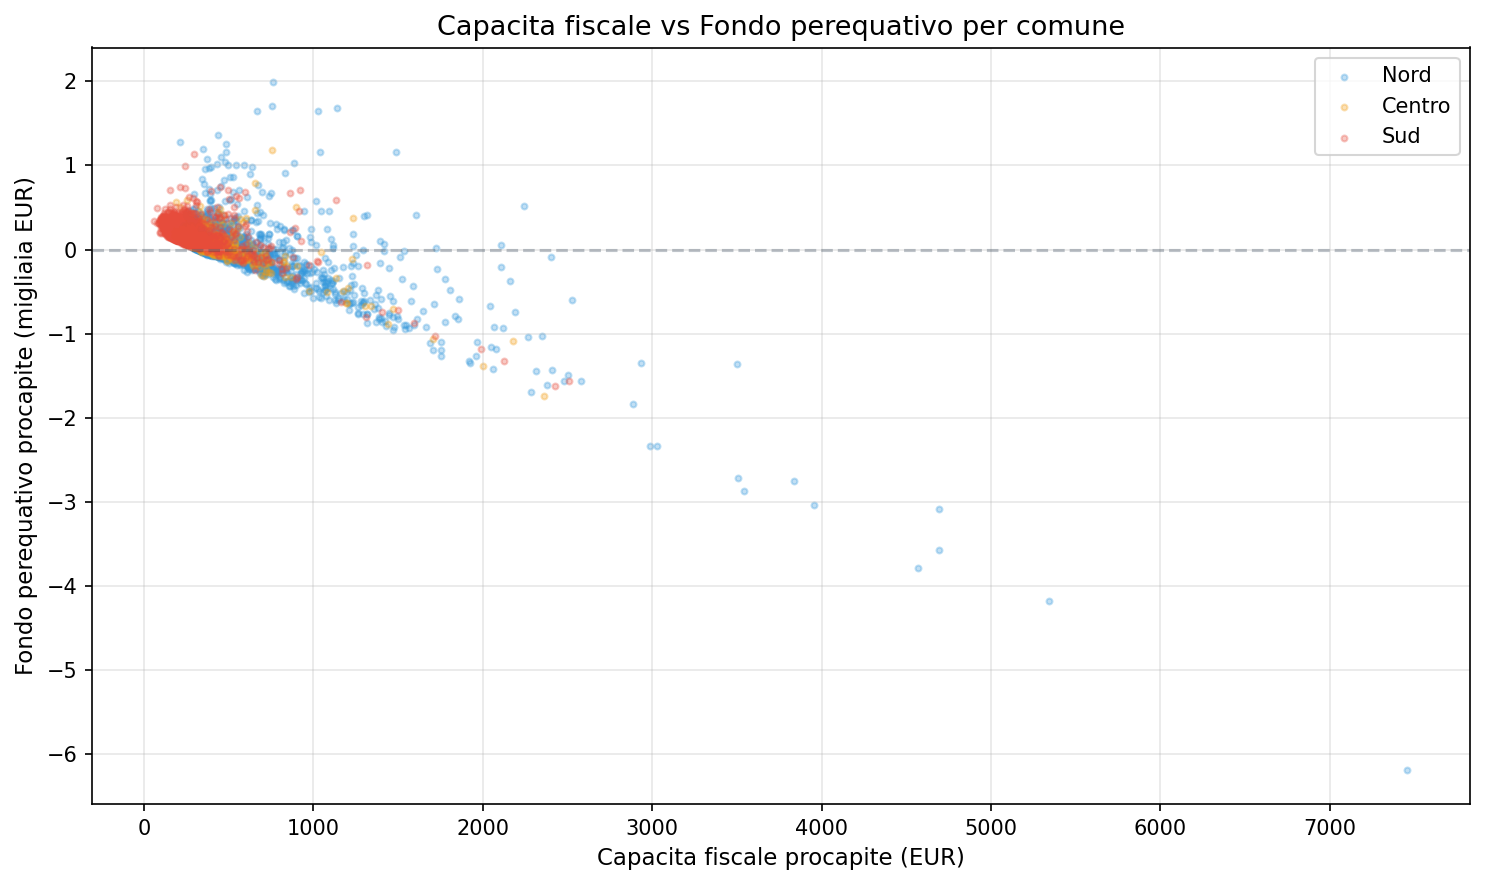

Salvato: figures/opencivitas_scatter.png


In [4]:
# Grafico: scatter CF vs FP
df = con.execute(f"""
    SELECT comune, regione, popolazione,
           ROUND(capacita_fiscale / NULLIF(popolazione, 0), 0) AS cf_procapite,
           ROUND(fondo_perequativo / NULLIF(popolazione, 0), 0) AS fp_procapite
    FROM read_parquet('{GCS}')
    WHERE regione != 'ITALIA' AND popolazione > 0 AND popolazione < 500000
""").fetchdf()

macrozone = {
    'Nord': ['PIEMONTE', 'LOMBARDIA', 'VENETO', 'LIGURIA', 'EMILIA-ROMAGNA'],
    'Centro': ['TOSCANA', 'UMBRIA', 'MARCHE', 'LAZIO'],
    'Sud': ['ABRUZZO', 'MOLISE', 'CAMPANIA', 'PUGLIA', 'BASILICATA', 'CALABRIA', 'SARDEGNA', 'SICILIA']
}
color_map = {'Nord': '#3498db', 'Centro': '#f39c12', 'Sud': '#e74c3c'}
df['macrozona'] = df['regione'].apply(
    lambda r: 'Nord' if r in macrozone['Nord'] else ('Centro' if r in macrozone['Centro'] else 'Sud'))

fig, ax = plt.subplots(figsize=(10, 6))
for zona, color in color_map.items():
    subset = df[df['macrozona'] == zona]
    ax.scatter(subset['cf_procapite'], subset['fp_procapite'] / 1000,
               c=color, label=zona, alpha=0.3, s=8)
ax.axhline(y=0, color='#2c3e50', linestyle='--', alpha=0.3)
ax.set_xlabel('Capacita fiscale procapite (EUR)', fontsize=11)
ax.set_ylabel('Fondo perequativo procapite (migliaia EUR)', fontsize=11)
ax.set_title('Capacita fiscale vs Fondo perequativo per comune', fontsize=13)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/opencivitas_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvato: figures/opencivitas_scatter.png')

In [5]:
# 3. Contributori netti
contrib = con.execute(f"""
    SELECT 
           COUNT(*) AS comuni,
           ROUND(AVG(capacita_fiscale / NULLIF(popolazione, 0)), 0) AS avg_cf_procapite,
           ROUND(SUM(popolazione)) AS pop_totale
    FROM read_parquet('{GCS}')
    WHERE regione != 'ITALIA' AND popolazione > 0
      AND fondo_perequativo < 0
""").fetchdf()

tot_comuni = con.execute(f"SELECT count(*) FROM read_parquet('{GCS}') WHERE regione != 'ITALIA'").fetchone()[0]
tot_pop = con.execute(f"SELECT SUM(popolazione) FROM read_parquet('{GCS}') WHERE regione != 'ITALIA'").fetchone()[0]

display(contrib)
n_contrib = int(contrib['comuni'].values[0])
print(f"Contributori netti: {n_contrib:,}/{tot_comuni:,} comuni ({n_contrib*100//tot_comuni}%)")
print(f"CF procapite medio: {int(contrib['avg_cf_procapite'].values[0]):,} EUR/ab (vs media nazionale ~340 EUR/ab)")

,comuni,avg_cf_procapite,pop_totale
0,1693,631,"47,498,732"


Contributori netti: 1,693/6,572 comuni (25%)
CF procapite medio: 631 EUR/ab (vs media nazionale ~340 EUR/ab)


In [6]:
# 4. Distribuzione CF
dist = con.execute(f"""
    SELECT
        ROUND(PERCENTILE_CONT(0.1) WITHIN GROUP (ORDER BY capacita_fiscale / NULLIF(popolazione, 0))) AS p10,
        ROUND(PERCENTILE_CONT(0.25) WITHIN GROUP (ORDER BY capacita_fiscale / NULLIF(popolazione, 0))) AS p25,
        ROUND(PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY capacita_fiscale / NULLIF(popolazione, 0))) AS p50,
        ROUND(PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY capacita_fiscale / NULLIF(popolazione, 0))) AS p75,
        ROUND(PERCENTILE_CONT(0.9) WITHIN GROUP (ORDER BY capacita_fiscale / NULLIF(popolazione, 0))) AS p90
    FROM read_parquet('{GCS}')
    WHERE regione != 'ITALIA' AND popolazione > 0
""").fetchdf()
display(dist)
r = dist.iloc[0]
print(f"Dal P10 ({int(r['p10'])} EUR/ab) al P90 ({int(r['p90'])} EUR/ab): x{int(r['p90']/r['p10'])}")

,p10,p25,p50,p75,p90
0,196,272,341,421,586


Dal P10 (196 EUR/ab) al P90 (586 EUR/ab): x2


In [7]:
con.close()
print('Completato.')

Completato.
